# Projet de théorie des graphes - ENSEEIHT - Ragot Cyrian

# Introduction

Nous étudions dans ce projet des essaims de satellites et en particulier leur communication dans un context de théorie des graphes. L'objectif principal est d'étudier les propriétés des graphes modélisant ces essaims pour différentes topologies (plus ou moins denses) et pour différentes capacités de portée communications entre satellites.

Ce projet est développé en python 3.13.1 et utilise plusieurs librairies externes telles que : 
-  csv (importation des données)
-  numpy (calcul matrciel)
-  scipy (calcul de la distance euclidenne)
-  matplotlib et seaborn (affichage des figures et histogrammes)
-  networkx (traitements sur les graphes)

Dans une première partie nous proposerons une modélisation pour les essaims de satellites sous forme de graphe. Ensuite nous étudierons plusieurs propriétés liées aux graphes en les considérants non valués puis dans une dernière partie nous prendrons comme coût le carré de la distance entre deux satellites.

### Importer les données :

In [1]:
import csv
import numpy as np
from scipy.spatial.distance import cdist

# path to topologies data files
path = "./topologies/"

# import topologies and compute distances between satellites in arrays
with open(path + 'topology_low.csv', mode ='r') as file:
    Pos_low = np.array(list(csv.reader(file))[1::][1::], dtype=np.float32) # get positions in array
    Dist_low = cdist(Pos_low, Pos_low, 'euclidean') # compute euclidian distances
with open(path + 'topology_avg.csv', mode ='r') as file:
    Pos_avg = np.array(list(csv.reader(file))[1::][1::], dtype=np.float32)
    Dist_avg = cdist(Pos_avg, Pos_avg, 'euclidean')      
with open(path + 'topology_high.csv', mode ='r') as file:
    Pos_high = np.array(list(csv.reader(file))[1::][1::], dtype=np.float32)
    Dist_high = cdist(Pos_high, Pos_high, 'euclidean')


# Partie 1 : modélisation sous forme de graphe

Nous avons choisis de modéliser un essaim dans comme un graphe simple non orienté (valué ou non selon les calculs effectués) dont les sommets sont les satellites et les arêtes lient les satellites qui sont à portée. C'est-à-dire qu'une arête existe entre deux satellites si la distance (ici euclidienne) entre les deux satellites est inférieure à la portée considérée. Le graphe est non orienté car une communication entre deux satellites se fait dans les deux sens. De plus, le graphe est simple car un satellite n'a pas besoin d'envoyer des informations à lui même et la communication entre deux satellites se fait sur un seul canal de communication.

Nous représentons graphiquement les différents essaims dans les trois configurations de densité (low, avg, high) et les trois niveaux de portée (20km, 40km, 60km) sur la figure 1. Pour un soucis de visibilité des graphes, les distances entre les sommets correspondent aux distances réelles entre les satellites grâce au layout *graphviz_layout* de *networkx*. Les positions des satellites ne sont donc représentées correctement mais leurs distances entre eux le sont.

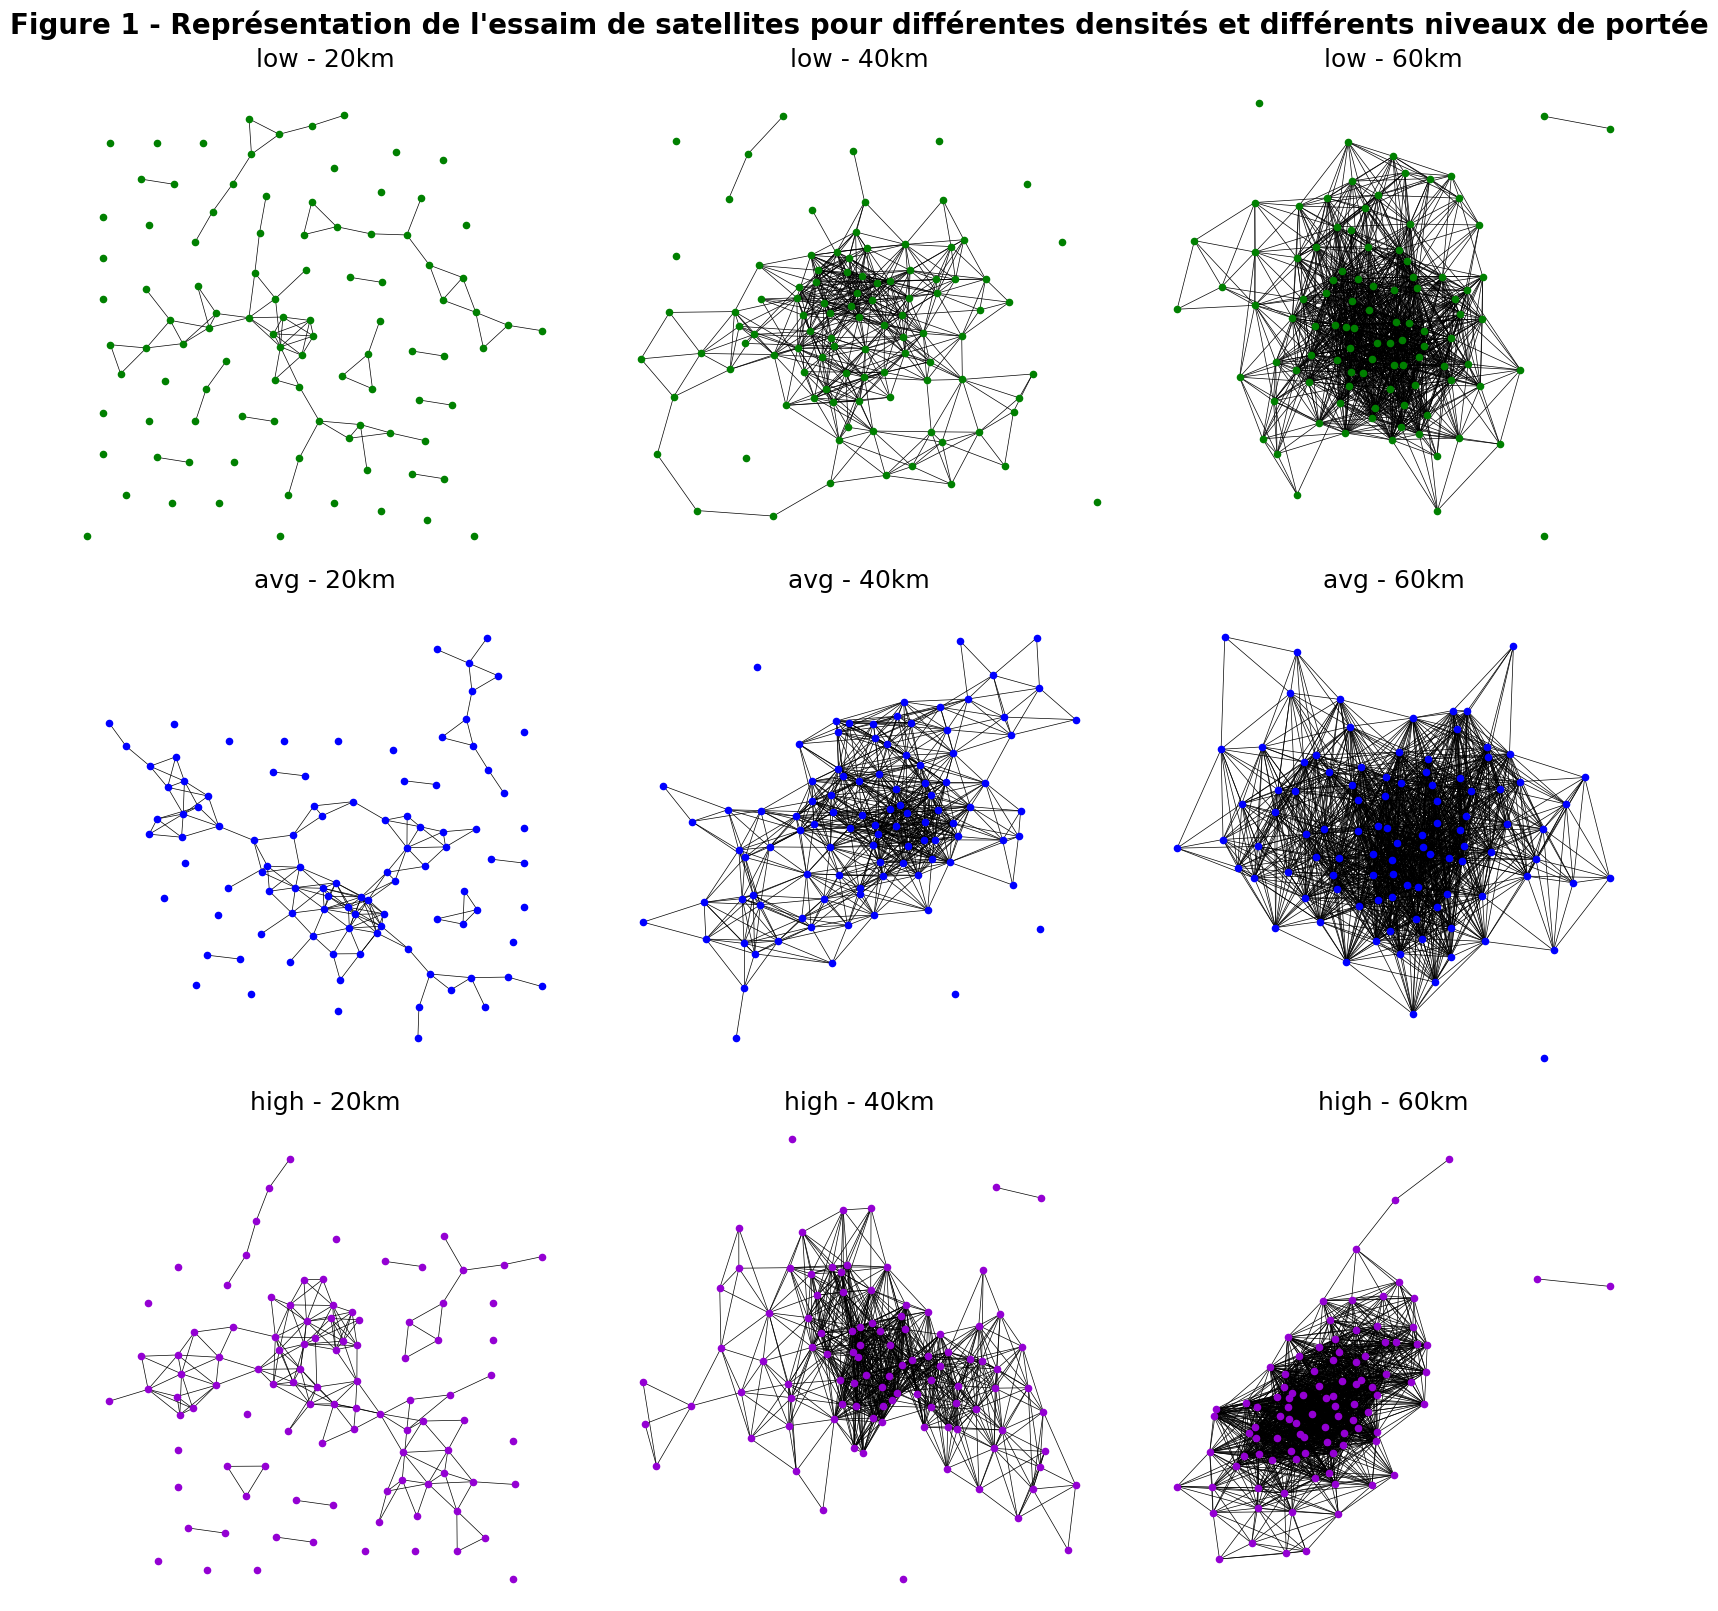

In [2]:
import networkx as nx
import numpy as np
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt

# compute adjacency matrixes with weight
# low
A_low_20 = np.where(Dist_low < 20000, np.multiply(Dist_low,Dist_low), 0)
A_low_40 = np.where(Dist_low < 40000, np.multiply(Dist_low,Dist_low), 0)
A_low_60 = np.where(Dist_low < 60000, np.multiply(Dist_low,Dist_low), 0)
# avg
A_avg_20 = np.where(Dist_avg < 20000, np.multiply(Dist_avg,Dist_avg), 0)
A_avg_40 = np.where(Dist_avg < 40000, np.multiply(Dist_avg,Dist_avg), 0)
A_avg_60 = np.where(Dist_avg < 60000, np.multiply(Dist_avg,Dist_avg), 0)
# high
A_high_20 = np.where(Dist_high < 20000, np.multiply(Dist_high,Dist_high), 0)
A_high_40 = np.where(Dist_high < 40000, np.multiply(Dist_high,Dist_high), 0)
A_high_60 = np.where(Dist_high < 60000, np.multiply(Dist_high,Dist_high), 0)


# compute graphs
# low
G_low_20 = nx.from_numpy_array(A_low_20, create_using=nx.Graph, parallel_edges=False)
G_low_20.remove_edges_from(nx.selfloop_edges(G_low_20)) # remove self looping (simple graphs)
G_low_40 = nx.from_numpy_array(A_low_40, create_using=nx.Graph, parallel_edges=False)
G_low_40.remove_edges_from(nx.selfloop_edges(G_low_40))
G_low_60 = nx.from_numpy_array(A_low_60, create_using=nx.Graph, parallel_edges=False)
G_low_60.remove_edges_from(nx.selfloop_edges(G_low_60))
# avg
G_avg_20 = nx.from_numpy_array(A_avg_20, create_using=nx.Graph, parallel_edges=False)
G_avg_20.remove_edges_from(nx.selfloop_edges(G_avg_20))
G_avg_40 = nx.from_numpy_array(A_avg_40, create_using=nx.Graph, parallel_edges=False)
G_avg_40.remove_edges_from(nx.selfloop_edges(G_avg_40))
G_avg_60 = nx.from_numpy_array(A_avg_60, create_using=nx.Graph, parallel_edges=False)
G_avg_60.remove_edges_from(nx.selfloop_edges(G_avg_60))
# high
G_high_20 = nx.from_numpy_array(A_high_20, create_using=nx.Graph, parallel_edges=False)
G_high_20.remove_edges_from(nx.selfloop_edges(G_high_20))
G_high_40 = nx.from_numpy_array(A_high_40, create_using=nx.Graph, parallel_edges=False)
G_high_40.remove_edges_from(nx.selfloop_edges(G_high_40))
G_high_60 = nx.from_numpy_array(A_high_60, create_using=nx.Graph, parallel_edges=False)
G_high_60.remove_edges_from(nx.selfloop_edges(G_high_60))


# graphs and plot positions dictionary used to iterate over the differents graphs easily
graphs_dict = {
    ("low","20"):(G_low_20,0,0),
    ("low","40"):(G_low_40,0,1),
    ("low","60"):(G_low_60,0,2),
    ("avg","20"):(G_avg_20,1,0),
    ("avg","40"):(G_avg_40,1,1),
    ("avg","60"):(G_avg_60,1,2),
    ("high","20"):(G_high_20,2,0),
    ("high","40"):(G_high_40,2,1),
    ("high","60"):(G_high_60,2,2)
}


# draw graphs
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(16, 16), layout="constrained")
fig.suptitle("Figure 1 - Représentation de l'essaim de satellites pour différentes densités et différents niveaux de portée", fontsize=20, fontweight="bold")

axs[0,0].set_title("low - 20km", fontsize=18)
nx.draw(G_low_20, node_size=20, width=0.5, node_color='green', ax=axs[0,0], pos=graphviz_layout(G_low_20) )
axs[0,1].set_title("low - 40km", fontsize=18)
nx.draw(G_low_40, node_size=20, width=0.5, node_color='green', ax=axs[0,1], pos=graphviz_layout(G_low_40))
axs[0,2].set_title("low - 60km", fontsize=18)
nx.draw(G_low_60, node_size=20, width=0.5, node_color='green', ax=axs[0,2], pos=graphviz_layout(G_low_60))

axs[1,0].set_title("avg - 20km", fontsize=18)
nx.draw(G_avg_20, node_size=20, width=0.5, node_color='blue', ax=axs[1,0], pos=graphviz_layout(G_avg_20))
axs[1,1].set_title("avg - 40km", fontsize=18)
nx.draw(G_avg_40, node_size=20, width=0.5, node_color='blue', ax=axs[1,1], pos=graphviz_layout(G_avg_40))
axs[1,2].set_title("avg - 60km", fontsize=18)
nx.draw(G_avg_60, node_size=20, width=0.5, node_color='blue', ax=axs[1,2], pos=graphviz_layout(G_avg_60))

axs[2,0].set_title("high - 20km", fontsize=18)
nx.draw(G_high_20, node_size=20, width=0.5, node_color='darkviolet', ax=axs[2,0], pos=graphviz_layout(G_high_20))
axs[2,1].set_title("high - 40km", fontsize=18)
nx.draw(G_high_40, node_size=20, width=0.5, node_color='darkviolet', ax=axs[2,1], pos=graphviz_layout(G_high_40))
axs[2,2].set_title("high - 60km", fontsize=18)
nx.draw(G_high_60, node_size=20, width=0.5, node_color='darkviolet', ax=axs[2,2], pos=graphviz_layout(G_high_60))


Nous remarquons sur ces graphes que plus la densité est faible ou la portée sont faibles, plus il y a de satellites isolés et moins de liens, c'est plutôt cohérent.

# Partie 2 : étude des graphes non valués

Dans cette partie, nous étudions des propriétés sur ces 9 graphes en ne considérant pas les distances entre sommets.

## Degré moyen, distribution du degré, moyenne et distribution du degré de clustering

Le degré d'un sommet est défini comme le nombre d'arêtes liées à ce sommet et le degré de clustering est défini comme la probabilité que deux nœuds soient connectés sachant qu'ils ont un voisin en commun.

Ainsi, la figure 2 montre les distributions des degrés des sommets pour chaque graphe et la moyenne des degrés avec un trait vertical en rouge. La figure 3 montre les distributions des degrés de clustering des sommets pour chaque graphe et la moyenne des degrés de la même façon.


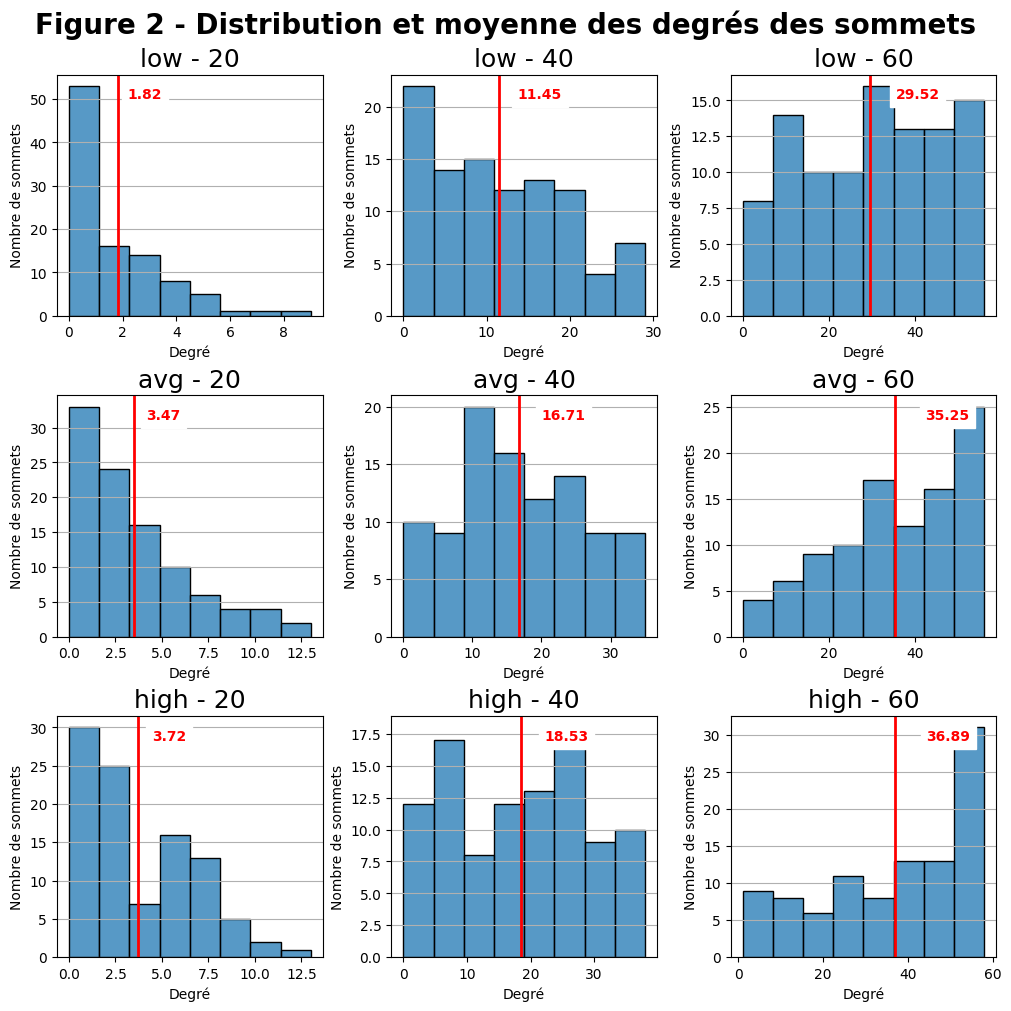

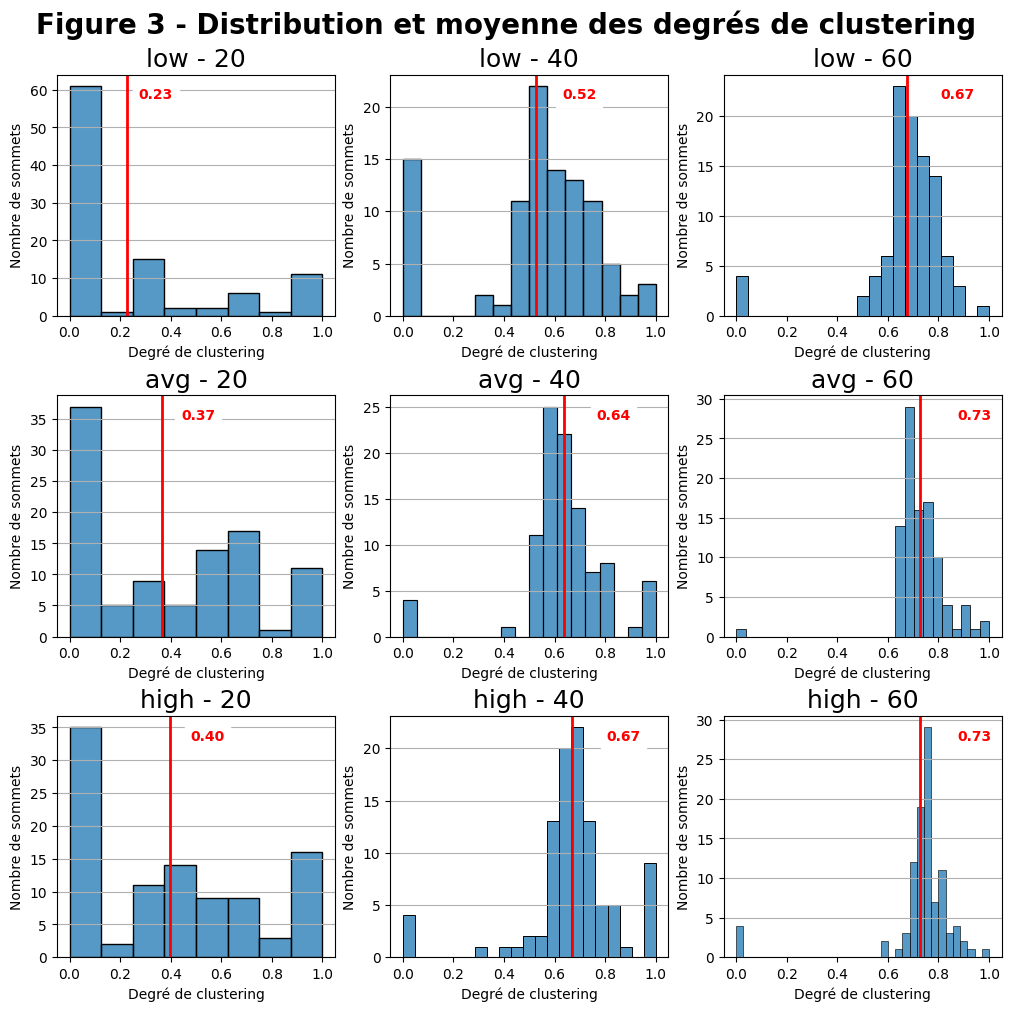

In [3]:
import networkx as nx
from scipy.stats import pmean
import seaborn as sns
import matplotlib.pyplot as plt

# compute nodes degrees mean and distribution and plot figure
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), layout="constrained")
fig.suptitle("Figure 2 - Distribution et moyenne des degrés des sommets", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    degrees = list(map(lambda x: x[1], G.degree))
    mean = pmean(degrees, 1)
    ax = sns.histplot(degrees, stat='count', ax=axs[i,j])
    ax.set_title(density + " - " + scope, fontsize=18)
    ax.set(xlabel="Degré", ylabel="Nombre de sommets")
    ax.axvline(mean, color='red', lw=2)
    ax.grid(axis='y')
    min_ylim, max_ylim = ax.get_ylim()
    ax.text(mean*1.2, max_ylim*0.9, '{:.2f}'.format(mean), color='red', weight='bold', backgroundcolor="white")
plt.show()

# compute clustering coefficent mean and distribution and plot figure
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), layout="constrained")
fig.suptitle("Figure 3 - Distribution et moyenne des degrés de clustering", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    clust_coeffs = list(nx.clustering(G).values())
    mean = pmean(clust_coeffs, 1)
    ax = sns.histplot(clust_coeffs, stat='count', ax=axs[i,j])
    ax.set_title(density + " - " + scope, fontsize=18)
    ax.set(xlabel="Degré de clustering", ylabel="Nombre de sommets")
    ax.axvline(mean, color='red', lw=2)
    ax.grid(axis='y')
    min_ylim, max_ylim = ax.get_ylim()
    ax.text(mean*1.2, max_ylim*0.9, '{:.2f}'.format(mean), color='red', weight='bold', backgroundcolor="white")
plt.show()


Nous remarquons que le degré des sommets augmente lorsque la portée ou la densité augmente en moyenne. On voit bien aussi que la courbe de l'histogramme se déplace vers des grands degrés dans ce cas. En effet, plus les satellites sont proches (densité) ou plus leurs ondes de communications sont puissantes (portée), plus ils peuvent être à portée d'un autre satellite et donc former des liens. Un grand degré nous indique qu'un seul satellite peut envoyer une information à un grand nombre de satellites différents et donc l'information peut être propagée plus rapidement.

Pour le degré de clustering, nous remarquons un comportement similaire, il augmente en moyenne lorsque la densité ou la portée augmente. On peut cependant voir un pic dans l'histogramme, au degré de clustering égal à 0, qui semble être présent sur tous les graphes (même si atténué pour de grandes densités et portées). Ce pic correspond aux satellites isolés qui forment peu de connections. On a bien pu observer sur tous les graphes qu'il reste toujours quelques satellites isolés, pour toutes les densités et portées.

Aussi, l'écart type est plus important pour des densités et portées élevées : les satellites sont moins éparses et forment des liens similaires avec leurs voisins. Ainsi, dans ces cas élevés, une information ne va pas se propager de façon très optimisée car un satellite a plus de chance d'envoyer l'information à un autre satellite qui a déjà reçu l'information précédemment.

## Nombre de cliques (et leurs ordres), nombre de composantes connexes (et leurs ordres)

Une clique est un sous ensemble de sommets dont chaque paire de sommets sont adjacentes à un même autre sommet de la clique, l'ordre de la clique est alors le nombre de sommets présents dans la clique. Une composante connexe est un sous graphe connexe qui ne fait partie d'aucun sous graphe connexe plus grand.

Ainsi, la figure 4 montre les distributions des ordres des cliques et donne le total de cliques pour chaque graphe tandis que la figure 5 montre les distributions des ordres des composantes connexes et donne le total de composantes connexes.

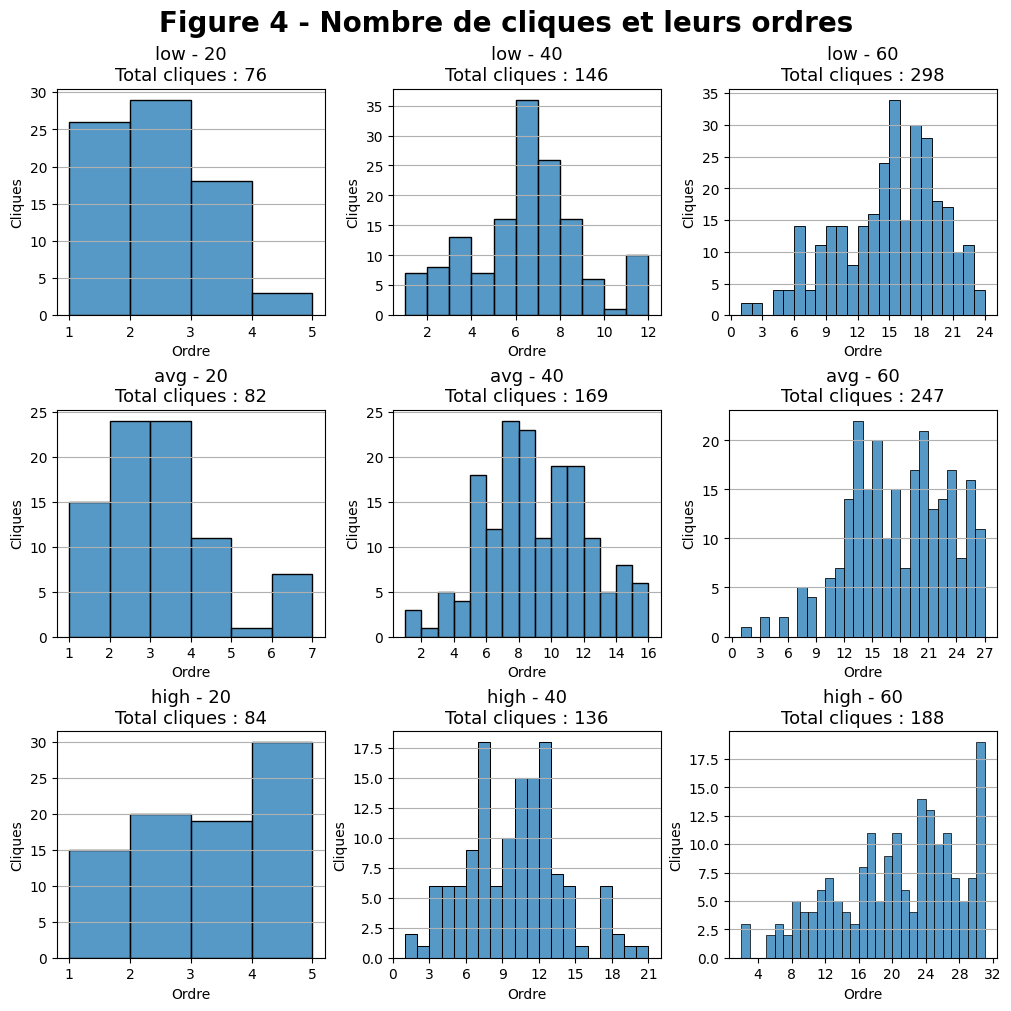

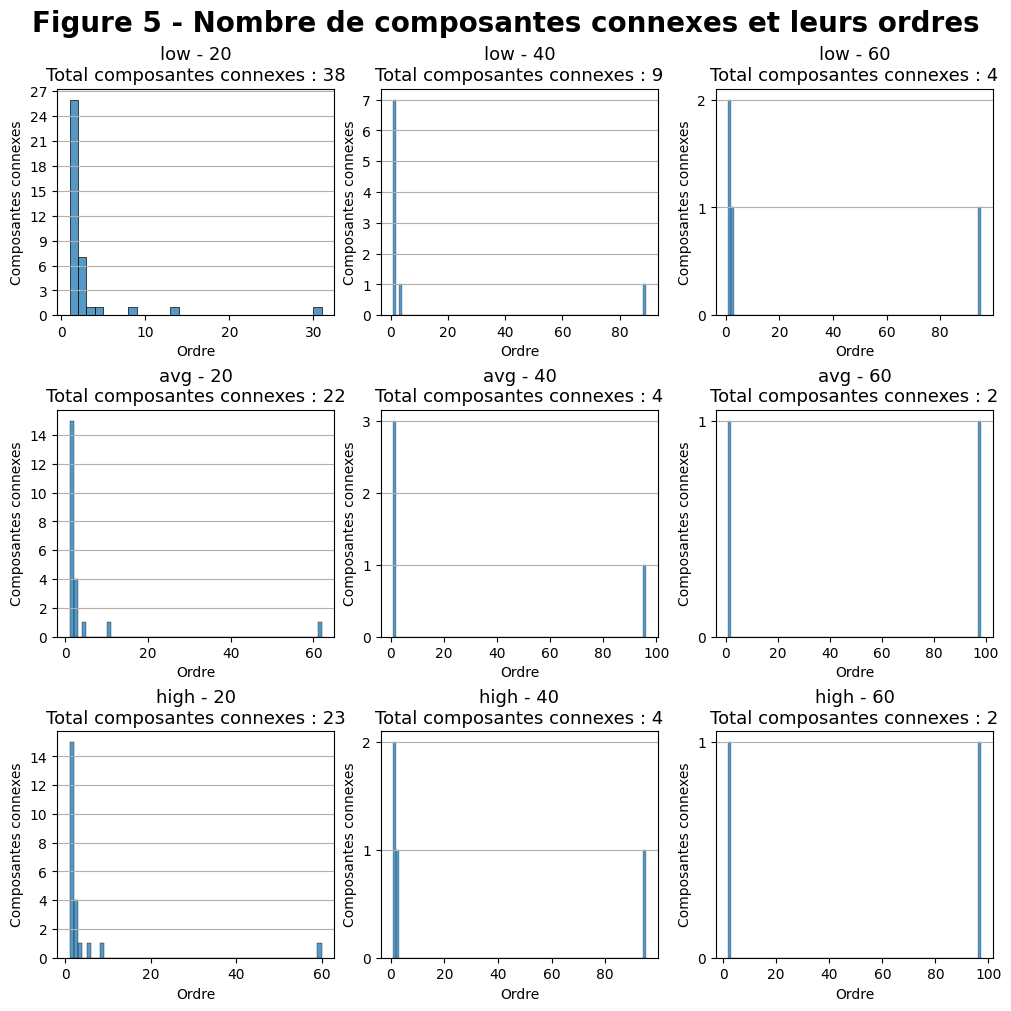

In [4]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# compute cliques number of vertices distribution and total number of cliques
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), layout="constrained")
fig.suptitle("Figure 4 - Nombre de cliques et leurs ordres", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    cliques = list(nx.find_cliques(G))
    nb_cliques = len(cliques)
    nb_vertices_by_clique = list(map(lambda x: len(x), cliques))
    ax = sns.histplot(nb_vertices_by_clique, stat='count', ax=axs[i,j], binwidth=1)
    ax.set_title(density + " - " + scope + "\nTotal cliques : " + str(nb_cliques), fontsize=13)
    ax.set(xlabel="Ordre", ylabel="Cliques")
    ax.grid(axis='y')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


# compute connected components number of vertices distribution and total number of connected components
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), layout="constrained")
fig.suptitle("Figure 5 - Nombre de composantes connexes et leurs ordres", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    conn_comp = list(nx.connected_components(G))
    nb_conn_comp = len(conn_comp)
    nb_vertices_by_comp_conn = list(map(lambda x: len(x), conn_comp))
    ax = sns.histplot(nb_vertices_by_comp_conn, stat='count', ax=axs[i,j], binwidth=1)
    ax.set_title(density + " - " + scope + "\nTotal composantes connexes : " + str(nb_conn_comp), fontsize=13)
    ax.set(xlabel="Ordre", ylabel="Composantes connexes")
    ax.grid(axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

Nous remarquons que les ordres et le nombre de cliques augmente avec la portée et la densité, ce qui est normal puisqu'il y a plus d'arêtes. Il est intéressant de trouver plusieurs cliques, et surtout de grandes cliques. En effet, au sein d'une même clique, une information peut être partagée en suivant un seul chemin et de manière à ce que un seul satellite reçoive l'information d'un seul autre satellite et la transmette à son tour à un seul troisisème satellite et ainsi de suite pour tous les satellites de la clique. En résumé, dans une clique, on peut éviter le problème de transmettre deux fois une information à un satellite par deux chemins différents.

Pour les composantes connexes, leur nombre total diminue lorsque la densité ou la portée augmente et c'est encore une fois évident qu'on attendait ce résultat. De plus, l'ordre de la plus grande composantes connexes augmente avec la densité ou la portée. On peut aussi remarquer que les histogrammes montrent surtout quelques pics dans les faibles ordres et un seul pic dans les grands ordre, on a toujours une composante connexe majoritaire, là ou se concentrent les satellites puis des satellites plus ou moins solitaires formant de petites composantes connexes nombreuses lorsque la densité ou la portée est trop faible. 

Or, plus on a de petites composantes connexes séparées, plus on a de chance qu'une information partant d'un satellites n'arrive pas à tous les satellites et même dans le meilleur des cas (densité high et portée 60km), un satellite éloigné forme une composante connexe d'ordre 1 et donc ne pourras jamais recevoir une information partagée dans la composante connexe formée par les autres satellites. On souhaite donc minimiser le nombre de composantes connexes et maximiser l'ordre de celles-ci pour maximiser nos chances d'envoyer une information à un maximum de satellites.

## Distribution des plus courts chemins et nombre des plus courts chemins

Nous calculons maintenant (figure 6) les distributions des longueurs des plus courts chemins et le total de plus courts chemins pour chaque graphe. Les distances sont comptées comme valant 1 sur chaque arête, on compte le nombre de sauts (graphes non valués). La fonction utilisée pour calculer les plus courts chemins utilise dijkstra et donne 2 plus courts chemins pour une seule paire de sommets (l'allée et le retour). Nous étudions ici des graphes non orientés mais gardons à l'esprit que les valeurs données ici sont donc toutes multiplées par un coefficient 2. Cela ne va pas impacter notre étude puisque nous nous intéressons aux ordres de grandeurs et à la comparaison de ces valeurs entre les graphes.

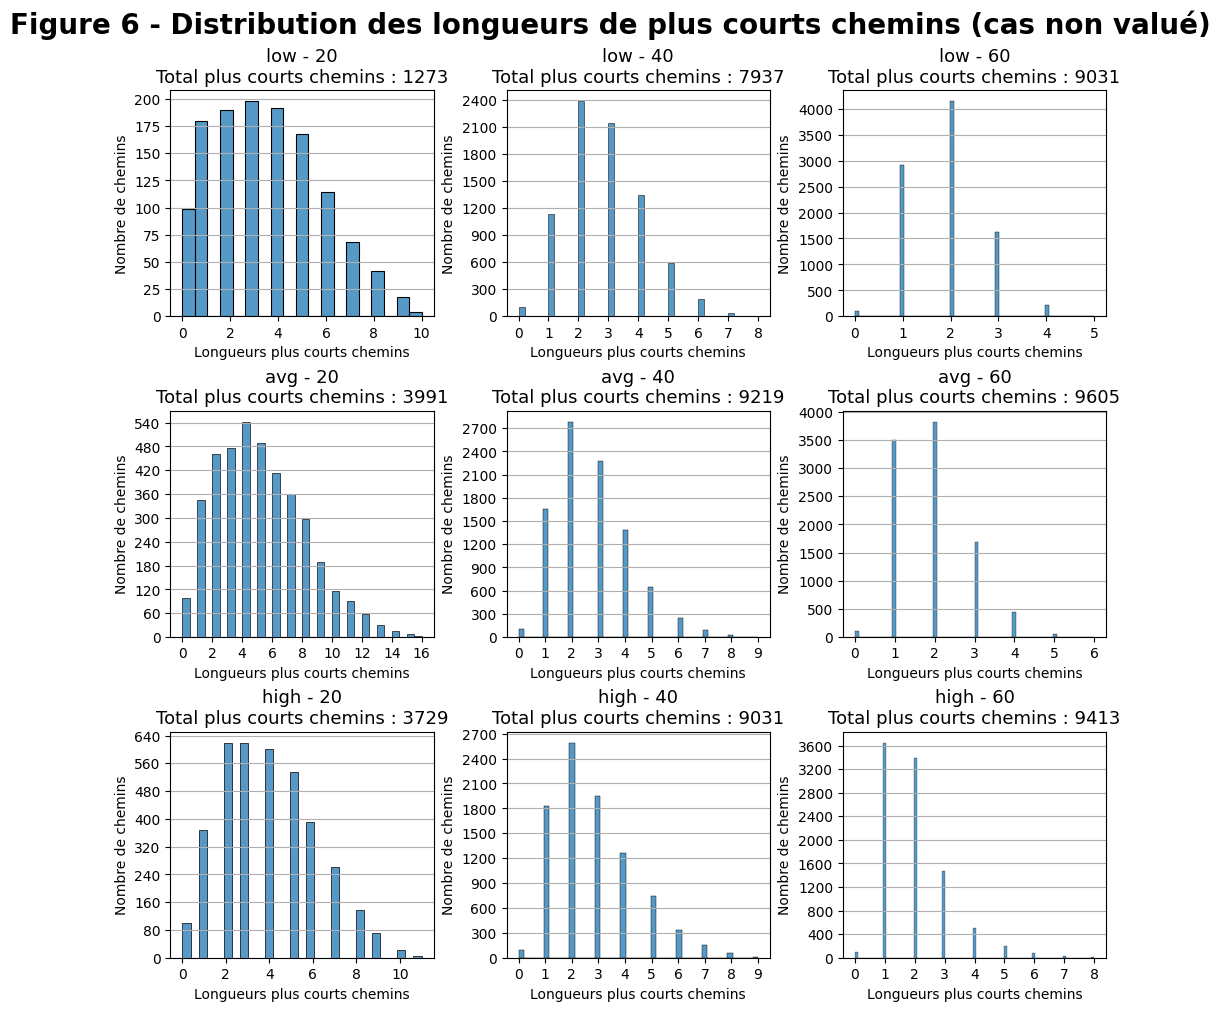

In [5]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

# compute shortest path lengths distribution (path length is computed as number os jump from source to target nodes)
fig, axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10), layout="constrained")
fig.suptitle("Figure 6 - Distribution des longueurs de plus courts chemins (cas non valué)", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    length_shortest_path = []
    for source, dic in nx.shortest_path_length(G, weight=None):
        length_shortest_path += list(dic.values())
    list(filter(lambda x: x != 0, length_shortest_path)) # don't count shortest paths of 0 (self nodes)
    nb_shortest_path = len(length_shortest_path)
    ax = sns.histplot(length_shortest_path, stat='count', ax=axs[i,j])
    ax.set_title(density + " - " + scope + "\nTotal plus courts chemins : " + str(nb_shortest_path), fontsize=13)
    ax.set(xlabel="Longueurs plus courts chemins", ylabel="Nombre de chemins")
    ax.grid(axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

On remarque une plus grande diversité de taille de chemins pour des configurations avec une faible portée. De plus, le nombre de plus courts chemins augmente lorsque la portée augmente et ce sont des chemins qui sont généralement plus courts. En effet, il y a plus d'arêtes donc plus de possibilités de former des chemins, et qui sont plus courts. Cependant, à portée fixée, les densités d'essaims moyennes (avg) ont plus de chemins au total. Cela est surprenant et c'est difficile à expliquer. En effet, le nombre de plus courts chemins devrait être égal au nombre de couples de sommets appartenants à une même composante connexe, et donc les essaims de densité élevée (high) devraient montrer plus de plus courts chemins. Mais surtout, le plus choquant est que nous devrions compter chaque plus court chemin deux fois comme expliqué précédemment (aller et retour) mais nous obtenons des nombres de plus courts chemins total impairs. Nous avons peut être soit un problème de modélisation, soit un problème de compréhension des fonctions du package networkx utilisées. 

Pour en revenir à nos satellites, nous cherchons plutôt à avoir plus de chemins courts dans un essaims pour améliorer la vitesse de transmission d'une information entre les satellites. Dans la pratique, nous chercherons donc à avoir une portée la plus grande possible si nous voulons aller plus vite mais cela se fera au dépend de la consommation d'énergie qu'il faut dépenser pour transmettre à de grandes portées.


# Partie 3 : étude des graphes valués

Dans cette partie, nous prenons en compte le poids associé à chaque connection entre satellites qui sera égal au carré de la distance entre deux satellites. Ainsi, la seule figure qui change est celle des plus courts chemins qui peuvent dépendre de la distances entre chaque sommet. Nous donnons les résultats pour un portée de 60km seulement sur la figure 7.

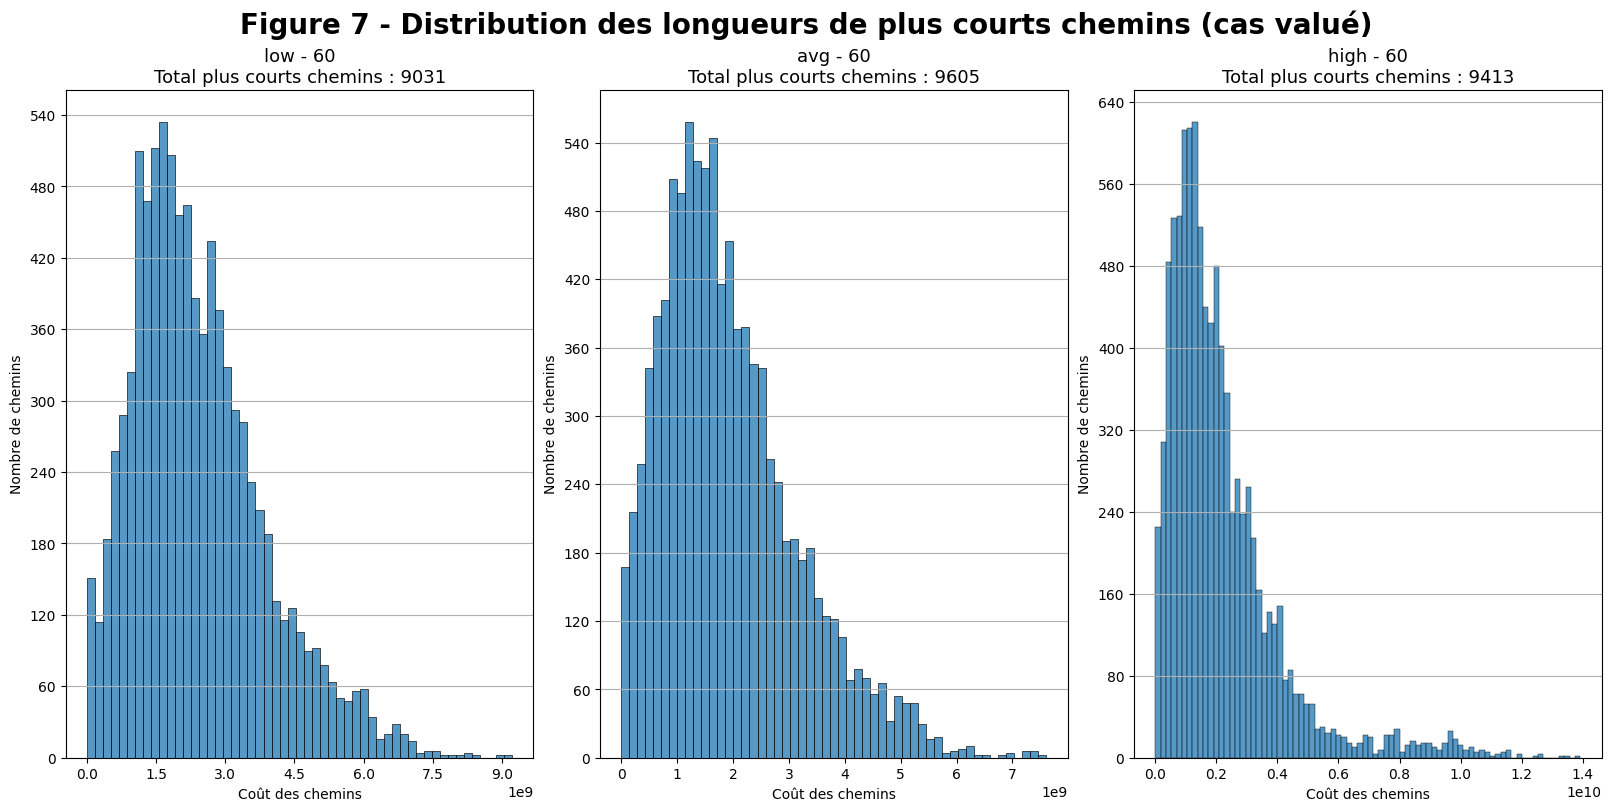

In [6]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

# compute shortest path lengths distribution (path length is computed as the power 2 of the distance between two nodes)
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(16, 8), layout="constrained")
fig.suptitle("Figure 7 - Distribution des longueurs de plus courts chemins (cas valué)", fontsize=20, fontweight="bold")
for (density, scope), (G,i,j) in graphs_dict.items():
    if scope == "60":

        length_shortest_path = []
        for source, dic in nx.shortest_path_length(G, weight='weight'):
            length_shortest_path += list(dic.values())
        list(filter(lambda x: x != 0, length_shortest_path))
        nb_shortest_path = len(length_shortest_path)
        ax = sns.histplot(length_shortest_path, stat='count', ax=axs[i])
        ax.set_title(density + " - " + scope + "\nTotal plus courts chemins : " + str(nb_shortest_path), fontsize=13)
        ax.set(xlabel="Coût des chemins", ylabel="Nombre de chemins")
        ax.grid(axis='y')
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

Ici, nous retrouvons des résultats similaires au cas non valué. Nous donnons donc les mêmes conclusions. On peut cependant noter que les nombres de plus courts chemins au total sont exactement les mêmes que pour les graphes non valués. C'est normal puisque le nombre de plus courts chemins devrait être égal au nombre de couples de sommets appartenants à une même composante connexe et que ce soit dans le cas valué ou non, les composantes connexes restent les mêmes.

# Conclusion

Finalement, dans cette étude nous avons pu modéliser les essaims de satellites par des graphes et ainsi étudier différents comportement de la communication entre satellites au travers des propriétés connues sur les graphes. Nous avons discuté des inconvénients et avantages liés à des portées de transmissions différentes et à des configurations d'essaims différentes. Ce que nous pouvons retenir c'est que l'augmentation de la portée permet une meilleure communication sur plusieurs aspect mais bien entendu cela a pour inconvénient d'utiliser plus de ressources énergétiques. Il faudrait alors poursuivre l'étude en prenant en compte ces coûts et les propriétés sur les essaims que l'ont souhaite mettre en avant selon le fonctionnement des transmissions et le type d'informations qui sont propagées. Un entre deux équitable entre performance et coût pourrait alors être trouvé grâce à une telle étude de modélisation sous forme de graphes.